# Student Credit Risk Prediction using Random Forest

## End-to-End Machine Learning Pipeline

### Objective
Develop a Random Forest model to predict student loan default risk using academic, financial, behavioral, and engineered risk indicators.

### Model
Random Forest Classifier (Binary Classification)

### Target Variable
default_flag

0 = Non-default
1 = Default

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay
)

# Phase 1 - Data Loading & Validation

Load and validate the processed dataset before model development.

In [3]:
df = pd.read_csv("master_v6_post_eda.csv")

print("Dataset Shape:")
print(df.shape)

Dataset Shape:
(21000, 38)


# Phase 2 - Data Preprocessing

Remove identifier and leakage columns and prepare the dataset for model training.

In [5]:
drop_cols = [
    "student_id",
    "default_probability"
]

df = df.drop(columns=drop_cols)

print(df.shape)

(21000, 36)


# Phase 3 - Feature Engineering

The dataset incorporates engineered risk indicators derived during dataset preparation.

## Engineered Features
- ECS
- GDI
- ACR
- CFRI
- OPR
- TGB
- SPRA
- SEI
- credit_bin
- synthetic_anomaly_flag

In [6]:
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

print("Encoding Complete")

Encoding Complete


C:\Users\mkart\AppData\Local\Temp\ipykernel_15148\1465515420.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns


# Phase 4 - Feature Selection

Separate features and target variable for model training.

In [7]:
X = df.drop("default_flag", axis=1)
y = df["default_flag"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (21000, 35)
Target Shape: (21000,)


# Phase 5 - Random Forest Model Training

Random Forest builds multiple decision trees and combines their predictions to improve robustness and reduce overfitting.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [9]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest Training Complete")

Random Forest Training Complete


# Phase 6 - Model Evaluation

## Objective
Evaluate the performance of the Random Forest model in predicting student loan default risk.

## Evaluation Metrics
- Classification Report
- Confusion Matrix
- ROC-AUC Score

In [10]:
y_pred = rf_model.predict(X_test)

y_prob = rf_model.predict_proba(X_test)[:, 1]

In [11]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      4064
           1       0.64      0.05      0.10       136

    accuracy                           0.97      4200
   macro avg       0.80      0.53      0.54      4200
weighted avg       0.96      0.97      0.96      4200



Confusion Matrix:
[[4060    4]
 [ 129    7]]


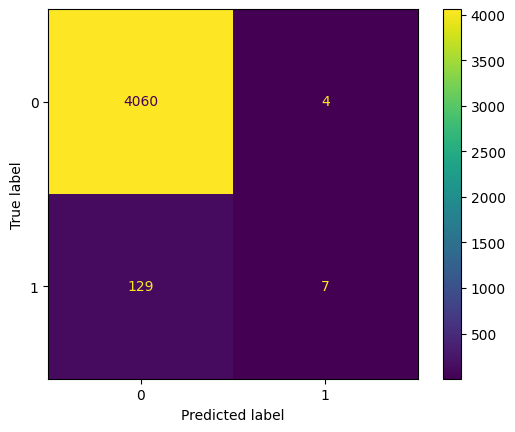

In [12]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm
).plot()

plt.show()

In [13]:
print("ROC-AUC Score:")
print(roc_auc_score(y_test, y_prob))

ROC-AUC Score:
0.8109186834182491


# Phase 7 - Model Explainability

## Objective
Analyze feature importance scores to understand which factors most influence default prediction.

Random Forest determines feature importance by measuring how much each feature reduces impurity across all decision trees.

In [14]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance["Importance (%)"] = (
    importance["Importance"] /
    importance["Importance"].sum()
) * 100

importance = importance.sort_values(
    by="Importance (%)",
    ascending=False
)

print(importance.head(15).round(2))

                  Feature  Importance  Importance (%)
31                   spra        0.12           11.95
32                    sei        0.07            6.88
29                    opr        0.05            5.00
28                   cfri        0.05            4.82
13      estimated_tuition        0.05            4.77
21      prior_delinquency        0.05            4.75
18      bill_payment_rate        0.05            4.73
27                    acr        0.05            4.64
14  estimated_living_cost        0.05            4.59
9     monthly_inflow_mean        0.05            4.53
10           cash_flow_cv        0.05            4.52
0           synthetic_age        0.04            4.36
30                    tgb        0.04            4.33
15    synthetic_debt_load        0.04            4.12
5    credit_hours_current        0.04            3.89


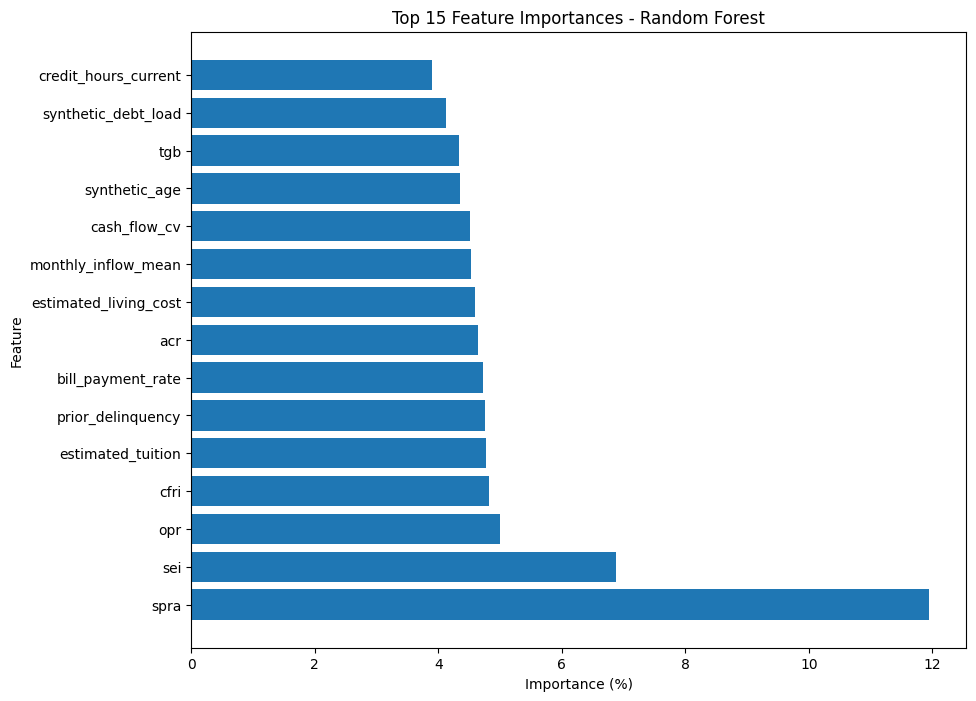

In [15]:
plt.figure(figsize=(10,8))

plt.barh(
    importance.head(15)["Feature"],
    importance.head(15)["Importance (%)"]
)

plt.xlabel("Importance (%)")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances - Random Forest")

plt.show()

# Phase 8 - Fairness & Stability

## Objective
Evaluate prediction consistency and error distribution on unseen data.

In [16]:
pred_dist = pd.Series(y_pred).value_counts()

print("Prediction Distribution:")
print(pred_dist)

Prediction Distribution:
0    4189
1      11
Name: count, dtype: int64


In [17]:
fp = ((y_pred == 1) & (y_test == 0)).sum()
fn = ((y_pred == 0) & (y_test == 1)).sum()

print("False Positives:", fp)
print("False Negatives:", fn)

False Positives: 4
False Negatives: 129


# Phase 9 - Prediction Pipeline

Student Information
↓
Data Preprocessing
↓
Feature Encoding
↓
Random Forest Model
↓
Default Probability Estimation
↓
Risk Classification

In [18]:
sample_student = X_test.iloc[[0]]

prediction = rf_model.predict(sample_student)
probability = rf_model.predict_proba(sample_student)

print("Predicted Class:", prediction[0])
print("Prediction Probability:", probability)

Predicted Class: 0
Prediction Probability: [[0.94 0.06]]
